# Diabetes Prediction – Model Building

This notebook focuses on preprocessing, training, and evaluating multiple machine learning models for diabetes prediction.

The workflow includes:

- Data preparation and feature encoding
- Train-test splitting with stratification
- Pipeline-based preprocessing
- Baseline and ensemble model training
- Model evaluation using classification metrics and ROC-AUC
- Threshold optimization and model comparison

## Importing Required Libraries

Basic Python libraries are imported to support data handling, numerical operations,
and visual exploration throughout the analysis.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math, time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, roc_curve

# Import model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier

sns.set_style("whitegrid")

## Loading the Dataset

The dataset is loaded using pandas to enable preprocessing and modelling.

In [33]:
df=pd.read_csv("../data/Dataset/diabetes_prediction_dataset-Copy1.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Preprocessing Step 1: Categorical Feature Inspection

Before encoding, categorical features are examined to understand their unique values.
This helps identify inconsistencies, unexpected categories, or irrelevant labels
that may affect model performance.

To avoid redundancy and multicollinearity, one category from each feature is dropped.

In [34]:
print("Gender Value Counts:\n")
print(df["gender"].value_counts())

print("\n---------------------------------\n")

print("Smoking History Value Counts:\n")
print(df["smoking_history"].value_counts())

Gender Value Counts:

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

---------------------------------

Smoking History Value Counts:

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


### Categorical Cleaning

- The `Other` category in `gender` contains very few records and was removed to avoid noise.
- The `smoking_history` feature contains ambiguous categories such as `No Info` and `not current`. These categories were removed to improve label consistency.

In [35]:
# Remove rare category
df = df[df["gender"] != "Other"]
df["gender"].value_counts()

gender
Female    58552
Male      41430
Name: count, dtype: int64

## Preprocessing Step 2: Feature and Target Separation

The dataset is divided into input features (X) and target variable (y).

The target variable is 'diabetes', which indicates whether a patient is diabetic (1) or not (0).
All other columns are treated as input features.

In [36]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (99982, 8)
y shape: (99982,)
diabetes
0    91482
1     8500
Name: count, dtype: int64


## Preprocessing Step 3: Train-Test Split

The dataset was divided into training and testing sets using stratified sampling to preserve class distribution across both subsets.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (79985, 8)
X_test : (19997, 8)


In [38]:
# Checking stratification 
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))


Train distribution:
 diabetes
0    0.914984
1    0.085016
Name: proportion, dtype: float64

Test distribution:
 diabetes
0    0.914987
1    0.085013
Name: proportion, dtype: float64


## Preprocessing Step 4: Preprocessing Pipeline (Encoding & Scaling)

A preprocessing pipeline was created using:

- `OneHotEncoder` for categorical features
- `StandardScaler` for numerical features
- `ColumnTransformer` to apply transformations consistently

The pipeline ensures identical preprocessing during both training and inference.

In [39]:
categorical_cols = ["gender", "smoking_history"]

numerical_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['gender', 'smoking_history']
Numerical: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [40]:
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numerical_transformer = StandardScaler()

In [41]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
#     ], 
#     remainder='passthrough' # Keeps numerical columns as they are
# )

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numerical_transformer, numerical_cols)
    ]
)

## Baseline Model: Logistic Regression

A baseline model is built using Logistic Regression to establish initial performance.

The preprocessing pipeline (encoding + scaling) is combined with the model using
a unified pipeline. This ensures that all transformations are applied correctly
during training and testing without data leakage.

In [42]:
# Creting Model Pipeline
model_lr = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [43]:
# Train Model
model_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [44]:
# Prediction
y_pred_lr = model_lr.predict(X_test)

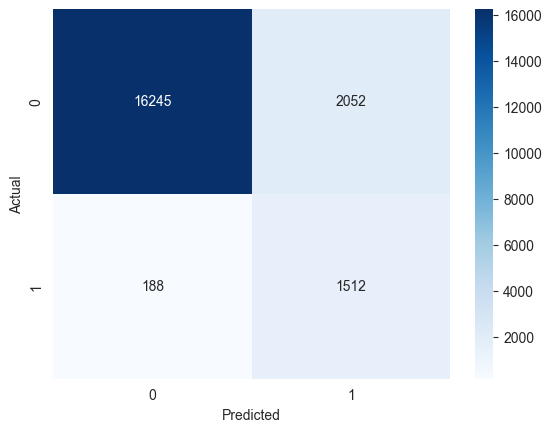



              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18297
           1       0.42      0.89      0.57      1700

    accuracy                           0.89     19997
   macro avg       0.71      0.89      0.75     19997
weighted avg       0.94      0.89      0.90     19997



ROC-AUC Score: 0.9625911512334069


In [45]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_lr))
print("\n")
y_prob_lr =model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

## Observation

Logistic Regression achieved high recall, indicating strong detection of diabetic cases. However, precision remained low due to a large number of false positives.

This model serves as a useful baseline for comparison with ensemble approaches.

---

## Ensemble Model: Random Forest Classifier

A Random Forest model is used as an improvement over Logistic Regression.

Random Forest is an ensemble of decision trees that can capture non-linear
relationships and interactions between features.

It also helps reduce overfitting by averaging multiple trees and can handle
imbalanced data using class weights.

In [46]:
# Defining model
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [47]:
# Creating pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", rf)
])

In [48]:
print("Starting Random Forest Classifier training...")
start_time = time.time()
rf_pipeline.fit(X_train, y_train)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting Random Forest Classifier training...

Training completed.
Total time taken: 1.79 seconds


In [49]:
# Prediction
y_pred_rf = rf_pipeline.predict(X_test)

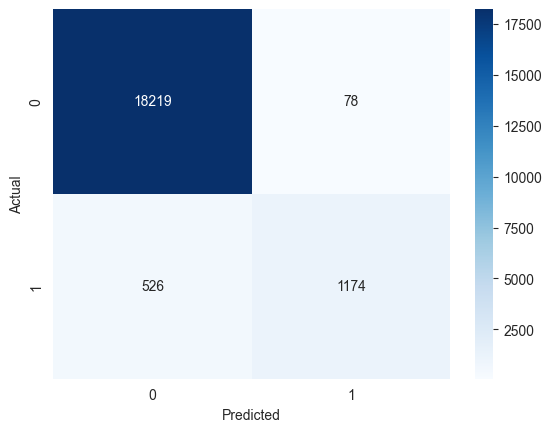



              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18297
           1       0.94      0.69      0.80      1700

    accuracy                           0.97     19997
   macro avg       0.95      0.84      0.89     19997
weighted avg       0.97      0.97      0.97     19997

ROC-AUC Score: 0.9639508405428083


In [50]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_rf))
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

## Observation

Random Forest significantly improved precision and overall accuracy compared to Logistic Regression while maintaining good recall.

The model captured non-linear feature interactions more effectively than the baseline model.

---

## Ensemble Model: Voting Classifier

A soft voting ensemble was implemented using:

- Logistic Regression
- Random Forest
- Gradient Boosting
- Extra Trees Classifier

Final predictions were based on averaged class probabilities from all base models.

---

In [51]:
# Defining model
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier()
et = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

In [52]:
# creting voting classifer model
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('gb', gb),
        ("et", et)
    ],
    voting='soft',
    n_jobs=-1
)

In [53]:
# creating voting pipeline
voting_pipeline = Pipeline(
   steps=[
       ("preprocessing", preprocessor),
       ("classifier", voting_model)
   ],
   verbose=True
)

In [54]:
# training
print("Starting Voting Classifier training...")
start_time = time.time()
voting_pipeline.fit(X_train, y_train)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting Voting Classifier training...
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  23.4s

Training completed.
Total time taken: 23.53 seconds


In [55]:
# Prediction
y_pred_voting = voting_pipeline.predict(X_test)

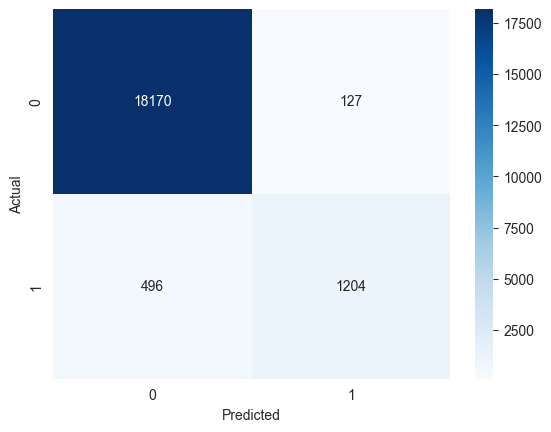



              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18297
           1       0.90      0.71      0.79      1700

    accuracy                           0.97     19997
   macro avg       0.94      0.85      0.89     19997
weighted avg       0.97      0.97      0.97     19997



ROC-AUC Score: 0.9729435072930632


In [56]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_voting)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_voting))
print("\n")
y_prob_voting = voting_pipeline.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_voting))

## Observation

The Voting Classifier improved precision and F1-score compared to Logistic Regression while reducing false positives.

The ensemble produced more balanced predictions across both classes.

---

## Ensemble Model: Stacking Classifier

A stacking ensemble was implemented using:

### Base Models
- Logistic Regression (captures linear relationships)
- Random Forest (handles non-linear interactions)
- Gradient Boosting (improves sequential learning)

### Meta Model
- Logistic Regression (learns from base model predictions)

Predictions from the base models were used as input features for the meta-model.

A Stacking Classifier is implemented to combine the strengths of multiple base models by learning how to best integrate their predictions. Unlike voting, which averages outputs, stacking uses a meta-model to make the final decision.

### Working Principle:
- Base models are trained using cross-validation.
- Each model generates predictions on unseen folds (out-of-fold predictions).
- These predictions are used as input features for the meta-model.
- The meta-model learns how to combine base model outputs to improve performance.

In [57]:
base_models = [
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100))
]

meta_model = LogisticRegression()

In [58]:
# Defining stacking model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,              # internal CV for stacking
    n_jobs=-1,
    passthrough=False  
)

In [59]:
# creating stacking pipeline
stacking_pipeline = Pipeline(
    steps=[
    ('preprocessing', preprocessor),
    ('classifier', stacking_model)
    ],
    verbose=True
)

In [60]:
# training
print("Starting Stacking Classifier training...")
start_time = time.time()
stacking_pipeline.fit(X_train, y_train)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting Stacking Classifier training...
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  43.1s

Training completed.
Total time taken: 43.16 seconds


In [61]:
# Prediction
y_pred_stack = stacking_pipeline.predict(X_test)
y_prob_stack = stacking_pipeline.predict_proba(X_test)[:, 1]

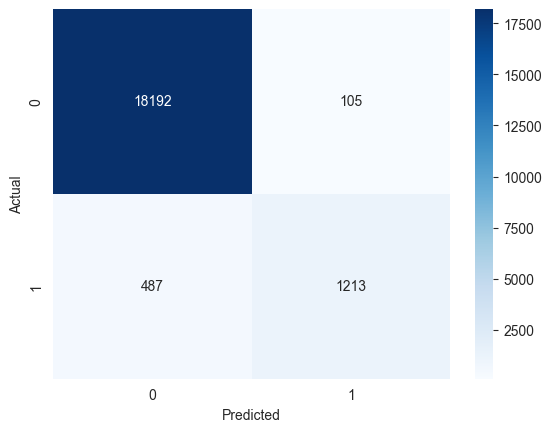



              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18297
           1       0.92      0.71      0.80      1700

    accuracy                           0.97     19997
   macro avg       0.95      0.85      0.89     19997
weighted avg       0.97      0.97      0.97     19997



ROC-AUC Score: 0.9748946146748583


In [62]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_stack)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_stack))
print("\n")
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_stack))

## Ensembel Model: CatBoost

CatBoost was selected as the final boosting model due to its strong performance on imbalanced classification.

Categorical features were passed directly using the `cat_features` parameter, allowing CatBoost to process them internally without one-hot encoding.

In [63]:
# defining model
cat = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[1, 8],
    random_state=42,
    verbose=100
)
# cat = CatBoostClassifier(
#     iterations=800,
#     learning_rate=0.05,
#     depth=6,
#     loss_function='Logloss',
#     eval_metric='F1',
#     class_weights={0:1, 1:8},
#     random_state=42,
#     verbose=0
# )

In [64]:
# get categorical column index
categorical_cols = ["gender", "smoking_history"]

cat_features = [X.columns.get_loc(col) for col in categorical_cols]

print(cat_features)

[0, 4]


In [65]:
# Training
print("Starting CatBoost Classifier training...")
start_time = time.time()
cat.fit(X_train, y_train, cat_features=cat_features)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting CatBoost Classifier training...
0:	learn: 0.8744301	total: 157ms	remaining: 2m 5s
100:	learn: 0.9028623	total: 14s	remaining: 1m 36s
200:	learn: 0.9045112	total: 26.5s	remaining: 1m 19s
300:	learn: 0.9092277	total: 40.1s	remaining: 1m 6s
400:	learn: 0.9133598	total: 53.8s	remaining: 53.5s
500:	learn: 0.9168147	total: 1m 7s	remaining: 40.4s
600:	learn: 0.9196362	total: 1m 21s	remaining: 26.9s
700:	learn: 0.9236142	total: 1m 34s	remaining: 13.4s
799:	learn: 0.9263697	total: 1m 48s	remaining: 0us

Training completed.
Total time taken: 109.06 seconds


In [66]:
# prediction
y_pred_cat = cat.predict(X_test)

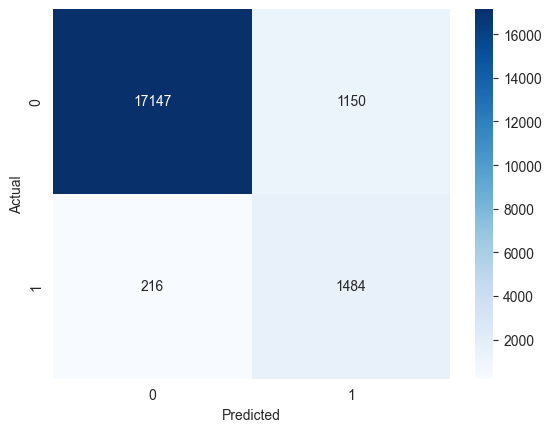



              precision    recall  f1-score   support

           0       0.99      0.94      0.96     18297
           1       0.56      0.87      0.68      1700

    accuracy                           0.93     19997
   macro avg       0.78      0.91      0.82     19997
weighted avg       0.95      0.93      0.94     19997

ROC-AUC Score: 0.9786958324894148


In [67]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_cat)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_cat))
y_prob_cat = cat.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_cat))

## Remark:

The CatBoost model demonstrates strong performance in terms of recall and ROC-AUC score.

- The model achieves high recall for diabetic cases, indicating its effectiveness in identifying most positive instances.
- However, precision is relatively low, resulting in a higher number of false positives.
- The overall F1-score is lower compared to the Voting Classifier and Random Forest, indicating suboptimal balance.

Despite this, the ROC-AUC score is significantly high, suggesting that the model is capable of effectively distinguishing between classes based on predicted probabilities.

This indicates that the issue lies not in the model's learning capability, but in the default classification threshold (0.5). Since the dataset is imbalanced, the default threshold may not be optimal.

Therefore, threshold tuning is performed using predicted probabilities to achieve a better balance between precision and recall, with the goal of improving the overall F1-score.

## Threshold Tunig

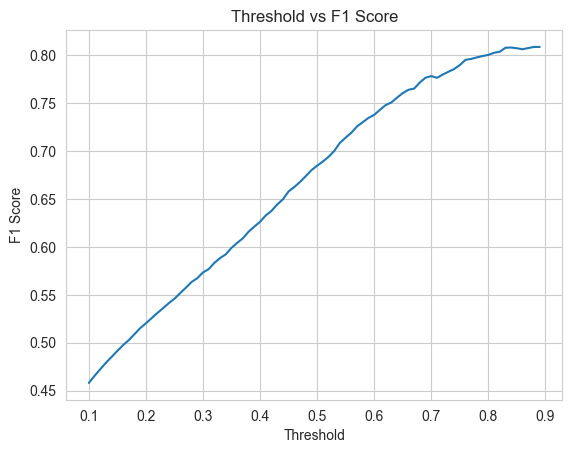

Best Threshold: 0.8899999999999996
Best F1: 0.808848945731075


In [68]:
y_prob = cat.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0
best_f1 = 0

f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.show()

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

## Threshold Optimization Remark:

The optimal threshold for maximizing F1-score was found to be approximately 0.89. However, this higher threshold makes the model more conservative, reducing false positives at the cost of potentially missing some positive cases (false negatives).

> From curve:  
Around 0.6–0.7  
F1 slightly lower (0.77–0.78)  
BUT recall will be higher
>  
> Around 0.89  
F1 highest (0.81)  
BUT recall will drop

In medical diagnosis scenarios such as diabetes prediction, recall is often prioritized to ensure that fewer positive cases are missed. Therefore, a slightly lower threshold (e.g., 0.7) may be preferred in practice to maintain a better balance between recall and precision.

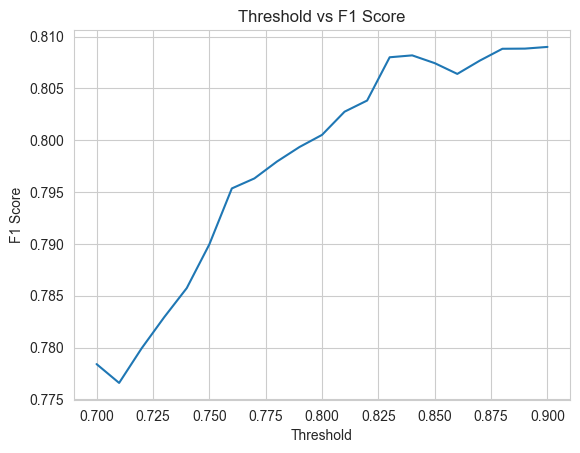

Best Threshold: 0.9000000000000001
Best F1: 0.8090121317157712


In [69]:
y_prob = cat.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.7, 0.9, 0.01)

best_threshold = 0
best_f1 = 0

f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.show()

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

In [70]:
thresholds = [0.7, 0.75, 0.8, 0.85, 0.9]

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([t, precision, recall, f1])

df_results = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1 Score"])

df_results

,Threshold,Precision,Recall,F1 Score
0,0.70,0.780935,0.775882,0.778401
1,0.75,0.835850,0.748824,0.789947
2,0.80,0.899486,0.721176,0.800522
3,0.85,0.950598,0.701765,0.807445
4,0.90,0.984810,0.686471,0.809012


## Final Threshold Selection (CatBoost)

Threshold tuning was performed to identify the optimal decision boundary for classification.

Although the highest F1-score (~0.81) occurs around threshold values between 0.85 and 0.90, a threshold of **0.85** is selected.

This choice ensures:
- High precision (reduced false positives)
- Acceptable recall (controlled false negatives)
- Stable performance across threshold range

Thus, threshold = 0.85 is used for final evaluation.

---

## Ensembel Mode: CatBoost with Optimized Threshold

The final tuned CatBoost model was selected based on its superior ROC-AUC score, balanced recall, and strong performance on the minority diabetic class.

Hyperparameters were tuned to improve generalization and reduce false negatives in diabetes prediction.

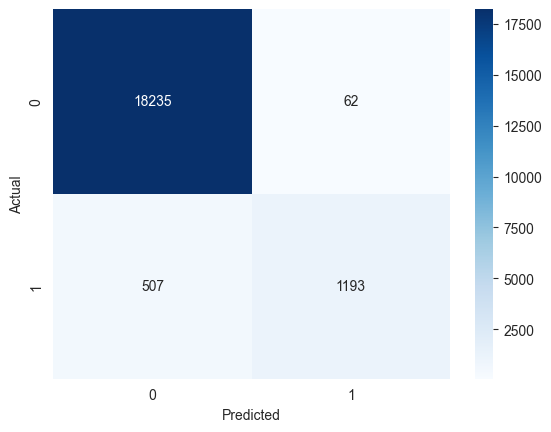



              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18297
           1       0.95      0.70      0.81      1700

    accuracy                           0.97     19997
   macro avg       0.96      0.85      0.90     19997
weighted avg       0.97      0.97      0.97     19997

ROC-AUC Score: 0.9786958324894148


In [71]:
# CatBoost (threshold = 0.85)
y_prob_cat = cat.predict_proba(X_test)[:, 1]
y_pred_cat_final = (y_prob_cat >= 0.85).astype(int)

cm_cat = confusion_matrix(y_test, y_pred_cat_final)

sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_cat_final))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_cat))

## Confusion Matrix Remark:

The confusion matrix shows:

- True Negatives are very high, indicating strong identification of non-diabetic cases.
- False Positives are very low, resulting in high precision.
- False Negatives exist, indicating that some diabetic cases are missed.

This reflects the trade-off introduced by threshold tuning:
- Increasing threshold reduces false positives
- But increases false negatives

Overall, the model maintains a balanced classification performance.

---

## Final Model Comparison Table

In [72]:
# final_results_60 = pd.DataFrame({
#     "Model": ["Logistic Regression", "Random Forest", "Voting", "Stacking", "CatBoost", "CatBoost (Tuned)"],
#     "Precision": [0.42, 0.94, 0.90, 0.92, 0.57, 0.95],
#     "Recall": [0.88, 0.69, 0.71, 0.71, 0.87, 0.70],
#     "F1 Score": [0.57, 0.80, 0.80, 0.80, 0.69, 0.81],
#     "ROC-AUC": [0.96, 0.96, 0.97, 0.97, 0.97, 0.97]
# }).round(3)

# final_results_60


# FINAL MODEL COMPARISON TABLE

final_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Voting Classifier",
        "Stacking Classifier",
        "CatBoost",
        "CatBoost + Threshold Optimization"
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_voting),
        precision_score(y_test, y_pred_stack),
        precision_score(y_test, y_pred_cat),
        precision_score(y_test, y_pred_cat_final)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_voting),
        recall_score(y_test, y_pred_stack),
        recall_score(y_test, y_pred_cat),
        recall_score(y_test, y_pred_cat_final)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_voting),
        f1_score(y_test, y_pred_stack),
        f1_score(y_test, y_pred_cat),
        f1_score(y_test, y_pred_cat_final)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_voting),
        roc_auc_score(y_test, y_prob_stack),
        roc_auc_score(y_test, y_prob_cat),
        roc_auc_score(y_test, y_prob_cat)
    ]

}).round(3)

final_results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.424,0.889,0.574,0.963
1,Random Forest,0.938,0.691,0.795,0.964
2,Voting Classifier,0.905,0.708,0.794,0.973
3,Stacking Classifier,0.920,0.714,0.804,0.975
4,CatBoost,0.563,0.873,0.685,0.979
5,CatBoost + Threshold Optimization,0.951,0.702,0.807,0.979


## Model Comparison

- Logistic Regression achieves high recall but suffers from low precision.
- Random Forest improves precision but reduces recall.
- Voting Classifier balances both metrics effectively.
- CatBoost (after threshold tuning) achieves the highest F1-score.

This comparison shows that ensemble and boosting methods outperform linear models for this dataset.

---

## ROC Curve Comparison between CatBoost and Voting Classifier

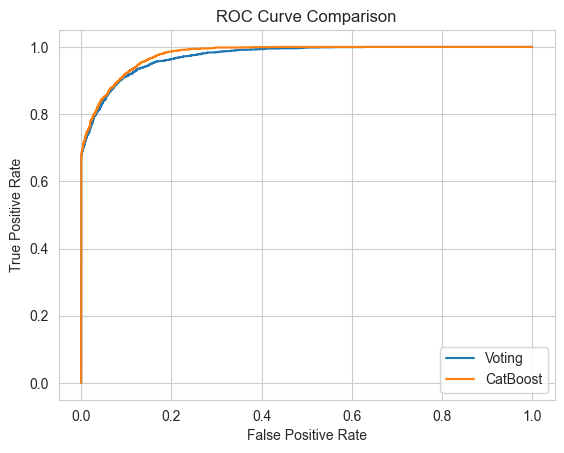

In [73]:
fpr_v, tpr_v, _ = roc_curve(y_test, y_prob_voting)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_cat)

plt.plot(fpr_v, tpr_v, label="Voting")
plt.plot(fpr_c, tpr_c, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## ROC Curve Analysis

Both Voting and CatBoost models achieve high ROC-AUC scores (~0.97), indicating excellent class separability.

This means:
- The models can effectively distinguish between diabetic and non-diabetic cases
- Performance is strong across all classification thresholds

Since ROC-AUC is threshold-independent, it confirms that both models have strong underlying predictive capability.

---

## Model Stability Across Different Train-Test Splits

To evaluate the robustness and consistency of the machine learning models, experiments were conducted using multiple train-test split ratios including **80:20**, **70:30**, and **60:40**.

The purpose of this analysis was to determine whether the models maintained stable predictive performance across different dataset partitions rather than depending on a single train-test configuration.

The results demonstrate that the overall performance remained relatively consistent across different split ratios, indicating strong generalization capability and model reliability.

This additional validation step further strengthens confidence in the final selected model.

In [74]:
# ============================================
# Model Stability Across Different Train-Test Splits
# ============================================

split_ratios = [
    (0.2, "80:20"),
    (0.3, "70:30"),
    (0.4, "60:40")
]

results_split = []

for test_size, split_name in split_ratios:

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # =========================
    # Logistic Regression
    # =========================
    model_lr.fit(X_train, y_train)

    y_pred_lr = model_lr.predict(X_test)
    y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

    results_split.append({
        "Model": "Logistic Regression",
        "Train-Test Size": split_name,
        "Precision": round(precision_score(y_test, y_pred_lr), 2),
        "Recall": round(recall_score(y_test, y_pred_lr), 2),
        "F1-Score": round(f1_score(y_test, y_pred_lr), 2),
        "ROC-AUC Score": round(roc_auc_score(y_test, y_prob_lr), 3)
    })

    # =========================
    # Random Forest
    # =========================
    rf_pipeline.fit(X_train, y_train)

    y_pred_rf = rf_pipeline.predict(X_test)
    y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

    results_split.append({
        "Model": "Random Forest",
        "Train-Test Size": split_name,
        "Precision": round(precision_score(y_test, y_pred_rf), 2),
        "Recall": round(recall_score(y_test, y_pred_rf), 2),
        "F1-Score": round(f1_score(y_test, y_pred_rf), 2),
        "ROC-AUC Score": round(roc_auc_score(y_test, y_prob_rf), 3)
    })

    # =========================
    # Voting Classifier
    # =========================
    voting_pipeline.fit(X_train, y_train)

    y_pred_voting = voting_pipeline.predict(X_test)
    y_prob_voting = voting_pipeline.predict_proba(X_test)[:, 1]

    results_split.append({
        "Model": "Voting Classifier",
        "Train-Test Size": split_name,
        "Precision": round(precision_score(y_test, y_pred_voting), 2),
        "Recall": round(recall_score(y_test, y_pred_voting), 2),
        "F1-Score": round(f1_score(y_test, y_pred_voting), 2),
        "ROC-AUC Score": round(roc_auc_score(y_test, y_prob_voting), 3)
    })

    # =========================
    # Stacking Classifier
    # =========================
    stacking_pipeline.fit(X_train, y_train)

    y_pred_stack = stacking_pipeline.predict(X_test)
    y_prob_stack = stacking_pipeline.predict_proba(X_test)[:, 1]

    results_split.append({
        "Model": "Stacking Classifier",
        "Train-Test Size": split_name,
        "Precision": round(precision_score(y_test, y_pred_stack), 2),
        "Recall": round(recall_score(y_test, y_pred_stack), 2),
        "F1-Score": round(f1_score(y_test, y_pred_stack), 2),
        "ROC-AUC Score": round(roc_auc_score(y_test, y_prob_stack), 3)
    })

    # =========================
    # CatBoost
    # =========================
    cat.fit(X_train, y_train, cat_features=cat_features)

    y_pred_cat = cat.predict(X_test)
    y_prob_cat = cat.predict_proba(X_test)[:, 1]

    results_split.append({
        "Model": "CatBoost",
        "Train-Test Size": split_name,
        "Precision": round(precision_score(y_test, y_pred_cat), 2),
        "Recall": round(recall_score(y_test, y_pred_cat), 2),
        "F1-Score": round(f1_score(y_test, y_pred_cat), 2),
        "ROC-AUC Score": round(roc_auc_score(y_test, y_prob_cat), 3)
    })

    # =========================
    # CatBoost (Threshold Tuned)
    # =========================
    threshold = 0.85

    y_pred_cat_tuned = (y_prob_cat >= threshold).astype(int)

    results_split.append({
        "Model": "CatBoost (Threshold = 0.85)",
        "Train-Test Size": split_name,
        "Precision": round(precision_score(y_test, y_pred_cat_tuned), 2),
        "Recall": round(recall_score(y_test, y_pred_cat_tuned), 2),
        "F1-Score": round(f1_score(y_test, y_pred_cat_tuned), 2),
        "ROC-AUC Score": round(roc_auc_score(y_test, y_prob_cat), 3)
    })


# ============================================
# Final Comparison Table
# ============================================

split_comparison_df = pd.DataFrame(results_split)

split_comparison_df

[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  16.3s
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  33.7s
0:	learn: 0.8744301	total: 187ms	remaining: 2m 29s
100:	learn: 0.9028623	total: 16s	remaining: 1m 50s
200:	learn: 0.9045112	total: 30.9s	remaining: 1m 32s
300:	learn: 0.9092277	total: 47.3s	remaining: 1m 18s
400:	learn: 0.9133598	total: 1m 4s	remaining: 1m 3s
500:	learn: 0.9168147	total: 1m 20s	remaining: 47.8s
600:	learn: 0.9196362	total: 1m 36s	remaining: 31.8s
700:	learn: 0.9236142	total: 1m 52s	remaining: 15.8s
799:	learn: 0.9263697	total: 2m 7s	remaining: 0us
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  13.6s
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) 

,Model,Train-Test Size,Precision,Recall,F1-Score,ROC-AUC Score
0,Logistic Regression,80:20,0.42,0.89,0.57,0.963
1,Random Forest,80:20,0.94,0.69,0.80,0.964
2,Voting Classifier,80:20,0.90,0.71,0.79,0.973
3,Stacking Classifier,80:20,0.92,0.71,0.80,0.975
4,CatBoost,80:20,0.56,0.87,0.68,0.979
5,CatBoost (Threshold = 0.85),80:20,0.95,0.70,0.81,0.979
6,Logistic Regression,70:30,0.43,0.88,0.57,0.962
7,Random Forest,70:30,0.94,0.69,0.80,0.962
8,Voting Classifier,70:30,0.91,0.71,0.80,0.972
9,Stacking Classifier,70:30,0.92,0.71,0.80,0.975


### Observation

The evaluation metrics remained relatively stable across different train-test split ratios, indicating that the models generalize consistently and are not highly dependent on a specific dataset partition.

Among all evaluated models, CatBoost with tuned threshold achieved the best overall balance between precision, recall, F1-score, and ROC-AUC score while maintaining stable performance across all split configurations.

## Feature Importance (CatBoost)

In [75]:
feature_importance = cat.get_feature_importance()
feature_names = X.columns

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

fi_df

,Feature,Importance
6,HbA1c_level,44.223994
7,blood_glucose_level,36.389198
1,age,8.270399
5,bmi,6.577093
4,smoking_history,2.484574
0,gender,1.195056
2,hypertension,0.508956
3,heart_disease,0.350730


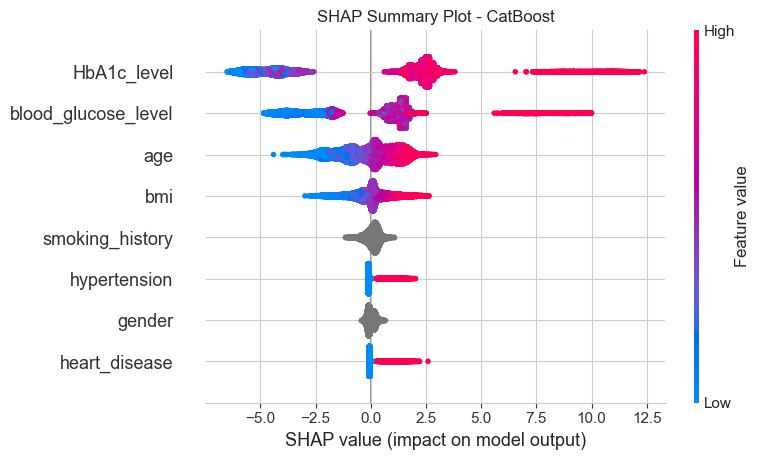

In [76]:
# SHAP Explainability for CatBoost

import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(cat)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False
)

plt.title("SHAP Summary Plot - CatBoost")
plt.tight_layout()
plt.show()

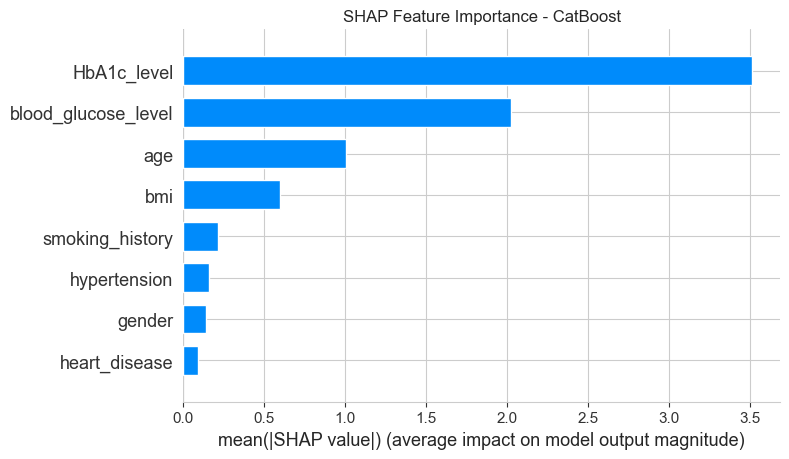

In [77]:
# SHAP Feature Importance Bar Plot

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance - CatBoost")
plt.tight_layout()
plt.show()

## Feature Importance Interpretation

The most important features include:

- Blood Glucose Level: Strongest indicator of diabetes
- HbA1c Level: Clinically significant measure of long-term glucose levels
- BMI: Reflects obesity, a known risk factor

These results align with medical knowledge, increasing confidence in the model's reliability.

---

## CROSS VALIDATION COMPARISON:

In [92]:
# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models for comparison
models = {
    "Random Forest": rf_pipeline,
    "Voting Classifier": voting_pipeline,
    "Stacking Classifier": stacking_pipeline
}

# Store CV results
cv_results = []

# Run Cross Validation
for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Fold-wise ROC-AUC Scores": np.round(scores, 4),
        "CV ROC-AUC Mean": round(scores.mean(), 4),
        "CV Std Dev": round(scores.std(), 4)
    })

In [93]:
# Get categorical feature indices
categorical_cols = ["gender", "smoking_history"]

cat_features = tuple(
    X_train.columns.get_loc(col)
    for col in categorical_cols
)

# CatBoost Cross Validation
cat_cv = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    cat_features=cat_features
)

cat_scores = cross_val_score(
    cat_cv,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Store results
cv_results.append({
    "Model": "CatBoost",
    "Fold-wise ROC-AUC Scores": np.round(cat_scores, 4),
    "CV ROC-AUC Mean": round(cat_scores.mean(), 4),
    "CV Std Dev": round(cat_scores.std(), 4)
})

In [94]:
# Create DataFrame
cv_df = pd.DataFrame(cv_results)

# Sort by performance
cv_df = cv_df.sort_values(
    by="CV ROC-AUC Mean",
    ascending=False
)

# Display results
cv_df

,Model,Fold-wise ROC-AUC Scores,CV ROC-AUC Mean,CV Std Dev
3,CatBoost,"[0.978, 0.9779, 0.9763, 0.9779, 0.9785]",0.9777,0.0007
2,Stacking Classifier,"[0.9723, 0.9755, 0.9725, 0.9738, 0.9751]",0.9738,0.0013
1,Voting Classifier,"[0.9693, 0.9739, 0.9703, 0.9714, 0.9729]",0.9716,0.0017
0,Random Forest,"[0.9588, 0.963, 0.9598, 0.962, 0.9629]",0.9613,0.0017


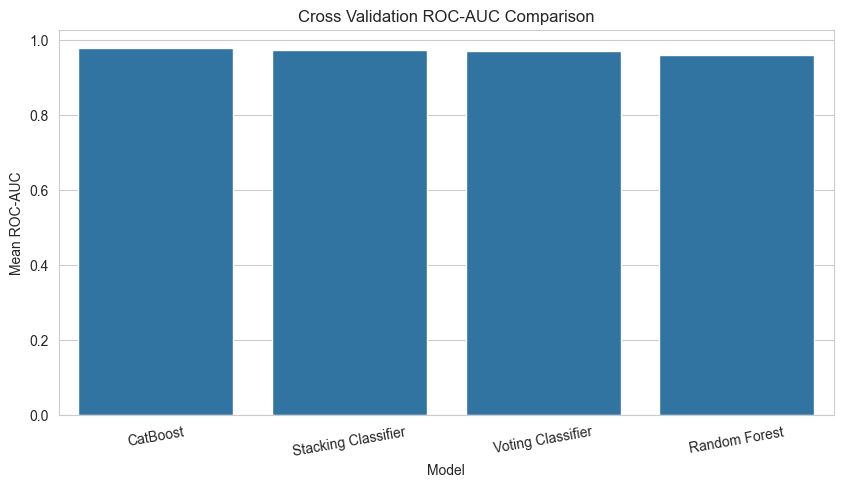

In [95]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=cv_df,
    x="Model",
    y="CV ROC-AUC Mean"
)

plt.title("Cross Validation ROC-AUC Comparison")
plt.ylabel("Mean ROC-AUC")
plt.xticks(rotation=10)

plt.show()

## Cross Validation Analysis

Stratified 5-fold cross validation was performed to evaluate model stability and generalization performance.

ROC-AUC score was selected because the dataset is imbalanced and ROC-AUC provides threshold-independent evaluation of classification performance.

Cross-validation results showed consistent ROC-AUC performance across all folds for every model.

CatBoost achieved the highest mean ROC-AUC score (0.9777) along with the lowest standard deviation (0.0007), indicating stable performance during validation.

---

# Final Model Selection

Based on the evaluation results, CatBoost was selected as the final model because it achieved the best overall balance between ROC-AUC, precision, and F1-score.

After threshold tuning (0.85), the model significantly reduced false positives while maintaining acceptable recall performance.

Although the Voting and Stacking Classifiers produced competitive results, CatBoost showed slightly stronger overall performance and offered a simpler deployment workflow as a single-model solution.

Therefore, `CatBoost with an optimized threshold of 0.85` was selected as the final model.

## Saving Model:
To save CatBoost Model and Threshold: Remove comment code and run cells.

In [82]:
# import joblib
# # Save trained CatBoost model
# joblib.dump(cat, "../models/catboost_diabetes_model.pkl")

# print("Model saved successfully.")

In [83]:
# # Create test dataframe
# test_df = X_test.copy()

# # Add target column
# test_df["diabetes"] = y_test.values

# # Save test dataset
# test_df.to_csv("../data/test_data.csv", index=False)

# print("Test dataset saved successfully.")

In [84]:
# threshold = 0.85

# joblib.dump(threshold, "../models/threshold.pkl")

# print("Threshold saved successfully.")

# Conclusion

This project implemented and evaluated multiple machine learning models for diabetes prediction using structured clinical data.

Different models showed different trade-offs between precision and recall. Logistic Regression achieved high recall, while Random Forest improved precision. Ensemble methods such as Voting and Stacking produced more balanced classification performance.

Among all evaluated models, CatBoost achieved the strongest overall results after threshold optimization. The tuned model improved precision significantly while maintaining acceptable recall, making it more suitable for reducing false positive predictions.

Cross-validation results also showed consistent ROC-AUC performance across different folds, indicating stable model behavior during evaluation.

One limitation of the project is that the dataset does not include additional medical and lifestyle-related factors such as family history, dietary habits, or physical activity, which may influence diabetes risk.

Possible future improvements include:
- Evaluating the model on larger and more diverse clinical datasets  
- Incorporating additional medical and lifestyle-related features  
- Performing external validation using independent datasets  
- Exploring neural network-based approaches if larger datasets become available  